# Bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from scipy.stats import zscore

# Coleta de Dados

In [ ]:
df = pd.read_csv('/content/dados_clientes.csv')

In [ ]:
df.head()

,id_cliente,nome,idade,genero,renda_anual,categoria_produto,valor_compra,data_compra,regiao
0,1006,Gabriela Rocha,40.0,Masculino,750000.000000,Eletrônicos,1084.904523,2024-01-15,Centro-Oeste
1,1019,Isabela Martins,42.0,Outro,174931.504986,Casa,984.100186,2024-04-05,Norte
2,1014,Gabriela Rocha,33.0,Outro,180660.619728,Moda,2017.981504,2024/03/10,Norte
3,1010,Sabrina Torres,58.0,Feminino,95133.980567,Esporte,4981.455814,2024/03/10,Nordeste
4,1007,Daniel Costa,42.0,Outro,96879.401953,Beleza,2052.315229,2024-06-22,Centro-Oeste


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_cliente         30 non-null     int64  
 1   nome               30 non-null     object 
 2   idade              28 non-null     float64
 3   genero             30 non-null     object 
 4   renda_anual        29 non-null     float64
 5   categoria_produto  30 non-null     object 
 6   valor_compra       28 non-null     float64
 7   data_compra        26 non-null     object 
 8   regiao             30 non-null     object 
dtypes: float64(3), int64(1), object(5)
memory usage: 2.2+ KB


In [ ]:
df.describe()

,id_cliente,idade,renda_anual,valor_compra
count,30.000000,28.000000,29.000000,28.000000
mean,1009.733333,38.892857,157162.103675,3920.147585
std,5.918605,12.561963,142393.899659,4108.469976
min,1000.000000,18.000000,39809.346415,984.100186
25%,1005.250000,31.000000,72155.261524,2017.981504
50%,1010.000000,40.000000,165339.227930,2612.869185
75%,1014.000000,42.250000,174931.504986,4393.001473
max,1019.000000,62.000000,750000.000000,20000.000000


# Observação dos Dados

In [ ]:
df.isnull().sum()

,0
id_cliente,0
nome,0
idade,2
genero,0
renda_anual,1
categoria_produto,0
valor_compra,2
data_compra,4
regiao,0


In [ ]:
df.duplicated().sum()

np.int64(0)

### **Idade**

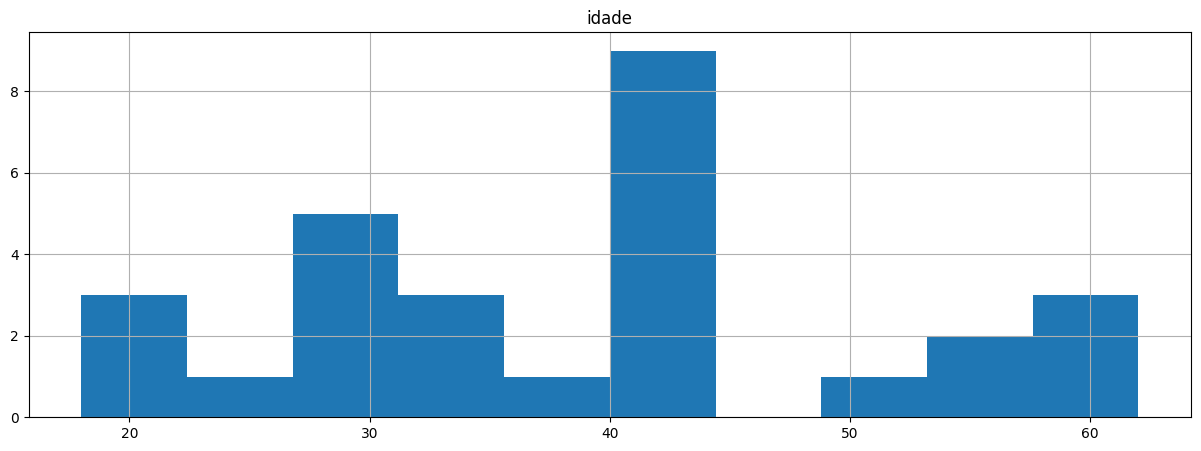

In [ ]:
df[['idade']].hist(bins = 10, figsize=(15,5))
plt.show()

# Dois valores faltando, nenhum outlier aparente, média e mediana próximos, com desvio padrão aceitável.


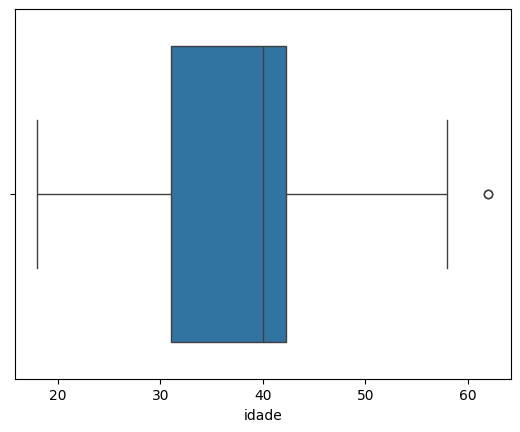

In [ ]:
sns.boxplot(x = df['idade'])
plt.show()

### Renda Anual

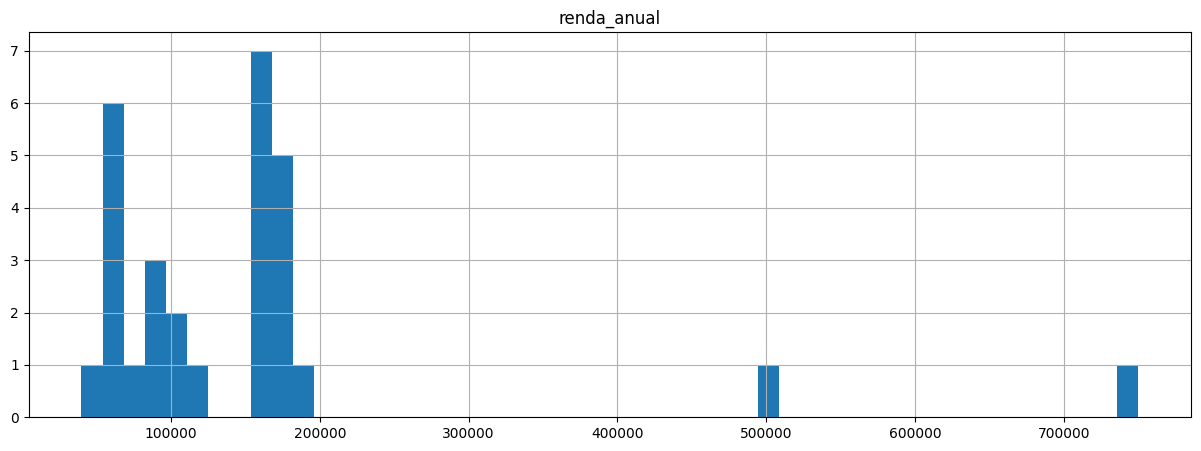

In [ ]:
df[['renda_anual']].hist(bins = 50, figsize=(15,5))
plt.show()

# Um valor faltando, dois possíveis outliers.

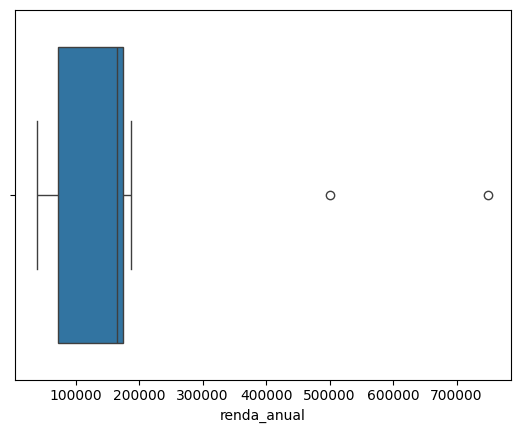

In [ ]:
sns.boxplot(x = df['renda_anual'])
plt.show()

### Valor da Compra

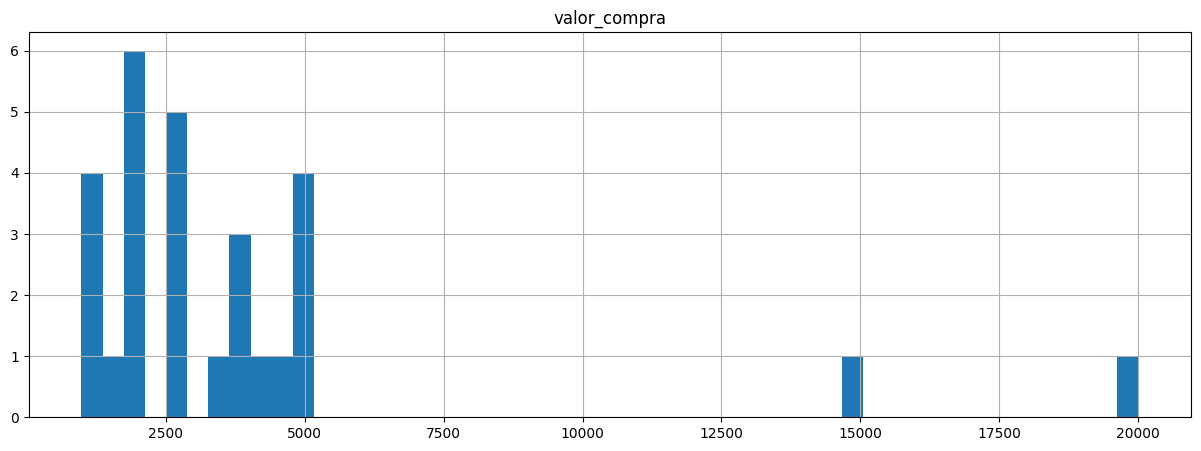

In [ ]:
df[['valor_compra']].hist(bins = 50, figsize=(15,5))
plt.show()

# Dois valores faltando, dois possíveis outliers.


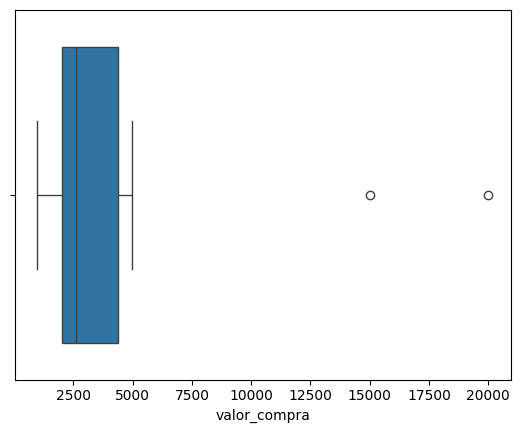

In [ ]:
sns.boxplot(x = df['valor_compra'])
plt.show()

# Tratando dados Ausentes

In [ ]:
df_limpo = df.copy()

In [ ]:
df_limpo["idade"] = df_limpo["idade"].fillna(df_limpo["idade"].median())
df_limpo["renda_anual"] = df_limpo["renda_anual"].fillna(df_limpo["renda_anual"].median())
df_limpo["valor_compra"] = df_limpo["valor_compra"].fillna(df_limpo["valor_compra"].median())

# Completando valores ausentes com a mediana.
# Não removi por se tratar de uma porcentagem muito alta.
# Optei em subistituir pela mediana, para que tenha menor influência de possíveis outliers e ainda possa ser usado.


In [ ]:
df_limpo.head()

,id_cliente,nome,idade,genero,renda_anual,categoria_produto,valor_compra,data_compra,regiao
0,1006,Gabriela Rocha,40.0,Masculino,750000.000000,Eletrônicos,1084.904523,2024-01-15,Centro-Oeste
1,1019,Isabela Martins,42.0,Outro,174931.504986,Casa,984.100186,2024-04-05,Norte
2,1014,Gabriela Rocha,33.0,Outro,180660.619728,Moda,2017.981504,2024/03/10,Norte
3,1010,Sabrina Torres,58.0,Feminino,95133.980567,Esporte,4981.455814,2024/03/10,Nordeste
4,1007,Daniel Costa,42.0,Outro,96879.401953,Beleza,2052.315229,2024-06-22,Centro-Oeste


In [ ]:
df_limpo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_cliente         30 non-null     int64  
 1   nome               30 non-null     object 
 2   idade              30 non-null     float64
 3   genero             30 non-null     object 
 4   renda_anual        30 non-null     float64
 5   categoria_produto  30 non-null     object 
 6   valor_compra       30 non-null     float64
 7   data_compra        26 non-null     object 
 8   regiao             30 non-null     object 
dtypes: float64(3), int64(1), object(5)
memory usage: 2.2+ KB


In [ ]:
df_limpo.describe()

,id_cliente,idade,renda_anual,valor_compra
count,30.000000,30.000000,30.000000,30.000000
mean,1009.733333,38.966667,157434.674484,3832.995692
std,5.918605,12.124308,139925.259729,3978.118077
min,1000.000000,18.000000,39809.346415,984.100186
25%,1005.250000,31.000000,77583.677680,2017.981504
50%,1010.000000,40.000000,165339.227930,2612.869185
75%,1014.000000,42.000000,173009.293206,4200.962989
max,1019.000000,62.000000,750000.000000,20000.000000


# Tratando Duplicatas

In [ ]:
df_limpo.duplicated().sum()

# Aparentemente não tem duplicata, mas...
# O ID único não é único, a ideia é criar um ID único de fato.
# Utilizando nome + idade + região + renda_aunal + genero.

np.int64(0)

In [ ]:
#O campo id_cliente apresenta inconsistência e não pode ser considerado identificador único de cliente.
# Vou criar um novo identificador único com base nos nomes, conferindo a idade e a região.
# (pois mesmo se o nome for igual, se a idade ou a região forem diferentes, é uma pessoa diferente)
df_limpo.groupby(["nome", "idade", "regiao", "genero", "renda_anual"]).size()

nome              idade  regiao        genero     renda_anual  
Bruno Lima        40.0   Sul           Outro      165339.227930    1
                  43.0   Nordeste      Feminino   165339.227930    1
                  62.0   Sudeste       Masculino  61183.669788     1
Carla Alves       18.0   Norte         Outro      93868.926146     1
Daniel Costa      40.0   Sudeste       Masculino  95133.980567     1
                                       Outro      165339.227930    1
                  42.0   Centro-Oeste  Outro      96879.401953     1
                         Nordeste      Outro      59979.405885     1
Felipe Oliveira   18.0   Sudeste       Outro      64872.601247     1
Gabriela Rocha    33.0   Norte         Outro      180660.619728    1
                  38.0   Centro-Oeste  Masculino  39809.346415     1
                  40.0   Centro-Oeste  Masculino  750000.000000    1
Henrique Silva    26.0   Centro-Oeste  Outro      72155.261524     1
                  53.0   Sudeste       Masculino  165339.227930    1
Isabela Martins   31.0   Norte         Masculino  500000.000000    1
                  42.0   Norte         Outro      174931.504986    1
João Pedro        18.0   Sudeste       Outro      64872.601247     1
                  40.0   Sul           Feminino   165339.227930    1
Leonardo Freitas  31.0   Sudeste       Feminino   167242.657866    1
                         Sul           Outro      176862.906234    1
Natália Teixeira  31.0   Sul           Outro      165339.227930    1
                  40.0   Sul           Feminino   174931.504986    1
Otávio Moura      32.0   Nordeste      Feminino   111934.514464    1
                  57.0   Norte         Masculino  64872.601247     1
Rafael Carvalho   57.0   Nordeste      Feminino   61183.669788     1
Sabrina Torres    31.0   Norte         Outro      187345.577422    1
                  32.0   Sudeste       Feminino   96879.401953     1
                  58.0   Nordeste      Feminino   95133.980567     1
                  62.0   Sul           Outro      174931.504986    1
Vitor Azevedo     41.0   Norte         Feminino   165339.227930    1
dtype: int64

In [ ]:
df_modelo = df_limpo.copy()
# Criando um novo DF para adicionar uma nova ID única para clientes.

In [ ]:
clientes = (
    df_modelo[
        ["nome", "idade", "genero", "renda_anual", "regiao"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)
# O novo ID será representado pelo nome + idade + genero + renda anual + regiao; se pelo menos um for diferente, é um novo cliente.

In [ ]:
clientes["id_cliente_novo"] = range(1, len(clientes) + 1)
# Criar ID único para clientes

In [ ]:
# Conectar vendas com clientes
df_modelo = df_modelo.merge(
    clientes,
    on=["nome", "idade", "genero", "renda_anual", "regiao"],
    how="left"
)

In [ ]:
df_modelo

,id_cliente,nome,idade,genero,renda_anual,categoria_produto,valor_compra,data_compra,regiao,id_cliente_novo
0,1006,Gabriela Rocha,40.0,Masculino,750000.000000,Eletrônicos,1084.904523,2024-01-15,Centro-Oeste,1
1,1019,Isabela Martins,42.0,Outro,174931.504986,Casa,984.100186,2024-04-05,Norte,2
2,1014,Gabriela Rocha,33.0,Outro,180660.619728,Moda,2017.981504,2024/03/10,Norte,3
3,1010,Sabrina Torres,58.0,Feminino,95133.980567,Esporte,4981.455814,2024/03/10,Nordeste,4
4,1007,Daniel Costa,42.0,Outro,96879.401953,Beleza,2052.315229,2024-06-22,Centro-Oeste,5
5,1006,Natália Teixeira,40.0,Feminino,174931.504986,Moda,2017.981504,2024-06-22,Sul,6
6,1018,Sabrina Torres,31.0,Outro,187345.577422,Beleza,2052.315229,2024-06-22,Norte,7
7,1010,Isabela Martins,31.0,Masculino,500000.000000,Casa,3937.436223,2024-06-22,Norte,8
8,1010,Bruno Lima,40.0,Outro,165339.227930,Casa,15000.000000,2024-06-22,Sul,9
9,1003,Vitor Azevedo,41.0,Feminino,165339.227930,Eletrônicos,2607.347662,2024-06-22,Norte,10


# Analizando Outliers

In [ ]:
df_outliers = df_modelo.copy()

### Idade

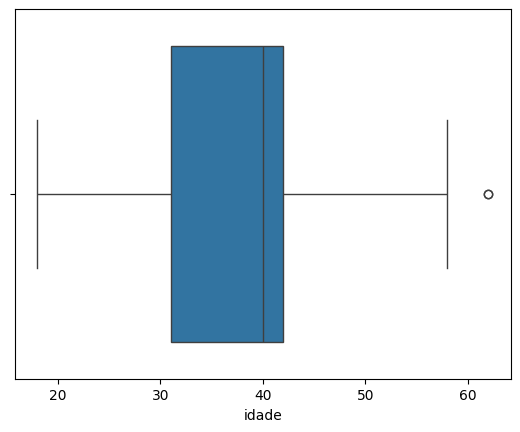

In [ ]:
sns.boxplot(x = df_outliers['idade'])
plt.show()

# Aparentemente, valores acima de 60 são outliers, mas ao usar o zscore, eles não aparecem como outliers.
# Por se tratar de idade, vou manter por causa do zscore.

In [ ]:
zscore(df_outliers['idade'])

array([ 0.08668523,  0.25446309, -0.50053729,  1.59668598,  0.25446309,
        0.08668523, -0.66831515, -0.66831515,  0.08668523,  0.17057416,
       -0.58442622, -0.08109263, -0.66831515, -1.0877598 ,  1.51279705,
       -1.75887125, -0.66831515,  1.51279705,  0.08668523,  1.93224171,
        1.17724133,  0.08668523,  0.33835202, -1.75887125, -1.75887125,
        0.25446309, -0.58442622, -0.66831515,  1.93224171,  0.08668523])

### Renda

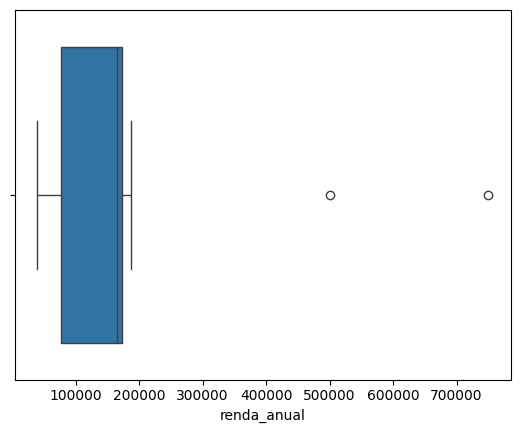

In [ ]:
sns.boxplot(x = df_outliers['renda_anual'])
plt.show()

# É visível que dois valores estão muito acima dos outros.

In [ ]:
zscore(df_outliers['renda_anual'])

# Mesmo usando o zscore temos um 4.3 e um 2.4.
# Um claramente outlier e outro muito próximo disso.
# Optei por remover devido ao IQR.

array([ 4.30726648,  0.12718178,  0.16882583, -0.45285419, -0.44016699,
        0.12718178,  0.21741777,  2.49005482,  0.05745699,  0.05745699,
       -0.33073369, -0.85500047,  0.14122084, -0.61988298, -0.67281952,
       -0.46204968,  0.05745699, -0.69963379,  0.05745699,  0.12718178,
        0.05745699, -0.45285419,  0.05745699, -0.67281952, -0.67281952,
       -0.7083874 , -0.44016699,  0.07129273, -0.69963379,  0.05745699])

### Valor da Compra

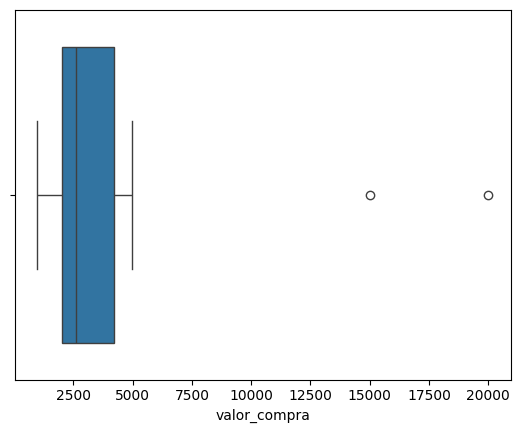

In [ ]:
sns.boxplot(x = df_outliers['valor_compra'])
plt.show()

# É visível dois valores muito acima dos outros.

In [ ]:
zscore(df_outliers['valor_compra'])

# Mesmo usando o zscore temos um 4.1 e um 2.8
# Um claramente outlier e outro muito próximo disso
# Optei por remover devido ao IQR

array([-0.70261124, -0.72838414, -0.46404915,  0.29362963, -0.45527096,
       -0.46404915, -0.45527096,  0.02670257,  2.85509552, -0.31336445,
        4.13345785,  0.22309838, -0.08084988, -0.46404915,  0.29362963,
        0.02670257, -0.28196281, -0.31195275, -0.31195275, -0.31195275,
       -0.31195275, -0.31336445, -0.61427419,  0.29362963, -0.72838414,
        0.11653795, -0.70261124, -0.03673397, -0.46404915,  0.25460634])

### Removendo Renda e valor compra

In [ ]:
# removendo renda
Q1 = df_outliers["renda_anual"].quantile(0.25)
Q3 = df_outliers["renda_anual"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

df_outliers = df_outliers[
    (df_outliers["renda_anual"] >= limite_inferior) &
    (df_outliers["renda_anual"] <= limite_superior)
]

In [ ]:
# removendo Venda
Q1 = df_outliers["valor_compra"].quantile(0.25)
Q3 = df_outliers["valor_compra"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

df_outliers = df_outliers[
    (df_outliers["valor_compra"] >= limite_inferior) &
    (df_outliers["valor_compra"] <= limite_superior)
]

In [ ]:
df_outliers.describe()

,id_cliente,idade,renda_anual,valor_compra,id_cliente_novo
count,26.000000,26.000000,26.000000,26.000000,26.000000
mean,1009.961538,39.461538,122914.095850,2883.366539,16.769231
std,6.302258,12.872391,51455.778350,1293.888241,8.663984
min,1000.000000,18.000000,39809.346415,984.100186,2.000000
25%,1004.250000,31.000000,66693.266316,2017.981504,10.500000
50%,1011.000000,40.000000,131109.314941,2612.869185,17.500000
75%,1014.750000,42.750000,166766.800382,3875.407115,23.750000
max,1019.000000,62.000000,187345.577422,4981.455814,30.000000


In [ ]:
df_outliers.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26 entries, 1 to 29
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_cliente         26 non-null     int64  
 1   nome               26 non-null     object 
 2   idade              26 non-null     float64
 3   genero             26 non-null     object 
 4   renda_anual        26 non-null     float64
 5   categoria_produto  26 non-null     object 
 6   valor_compra       26 non-null     float64
 7   data_compra        23 non-null     object 
 8   regiao             26 non-null     object 
 9   id_cliente_novo    26 non-null     int64  
dtypes: float64(3), int64(2), object(5)
memory usage: 2.2+ KB


# Encoding

In [ ]:
df_encoding = df_outliers.copy()

### genero

In [ ]:
df_encoding = pd.get_dummies(df_encoding, columns=['genero'])
df_encoding

,id_cliente,nome,idade,renda_anual,categoria_produto,valor_compra,data_compra,regiao,id_cliente_novo,genero_Feminino,genero_Masculino,genero_Outro
1,1019,Isabela Martins,42.0,174931.504986,Casa,984.100186,2024-04-05,Norte,2,False,False,True
2,1014,Gabriela Rocha,33.0,180660.619728,Moda,2017.981504,2024/03/10,Norte,3,False,False,True
3,1010,Sabrina Torres,58.0,95133.980567,Esporte,4981.455814,2024/03/10,Nordeste,4,True,False,False
4,1007,Daniel Costa,42.0,96879.401953,Beleza,2052.315229,2024-06-22,Centro-Oeste,5,False,False,True
5,1006,Natália Teixeira,40.0,174931.504986,Moda,2017.981504,2024-06-22,Sul,6,True,False,False
6,1018,Sabrina Torres,31.0,187345.577422,Beleza,2052.315229,2024-06-22,Norte,7,False,False,True
9,1003,Vitor Azevedo,41.0,165339.227930,Eletrônicos,2607.347662,2024-06-22,Norte,10,True,False,False
11,1002,Gabriela Rocha,38.0,39809.346415,Beleza,4705.590159,2024/03/10,Centro-Oeste,12,False,True,False
12,1001,Leonardo Freitas,31.0,176862.906234,Moda,3516.771258,2024-06-22,Sul,13,False,False,True
13,1011,Henrique Silva,26.0,72155.261524,Casa,2017.981504,2024/03/10,Centro-Oeste,14,False,False,True


### Categoria de Produto

In [ ]:
df_encoding['categoria_produto_label'] = df_encoding['categoria_produto'].astype('category').cat.codes
df_encoding

#Beleza -> 0
#Casa -> 1
#Eletrôniocos -> 2
#Esporte -> 3
#Moda -> 4

,id_cliente,nome,idade,renda_anual,categoria_produto,valor_compra,data_compra,regiao,id_cliente_novo,genero_Feminino,genero_Masculino,genero_Outro,categoria_produto_label
1,1019,Isabela Martins,42.0,174931.504986,Casa,984.100186,2024-04-05,Norte,2,False,False,True,1
2,1014,Gabriela Rocha,33.0,180660.619728,Moda,2017.981504,2024/03/10,Norte,3,False,False,True,4
3,1010,Sabrina Torres,58.0,95133.980567,Esporte,4981.455814,2024/03/10,Nordeste,4,True,False,False,3
4,1007,Daniel Costa,42.0,96879.401953,Beleza,2052.315229,2024-06-22,Centro-Oeste,5,False,False,True,0
5,1006,Natália Teixeira,40.0,174931.504986,Moda,2017.981504,2024-06-22,Sul,6,True,False,False,4
6,1018,Sabrina Torres,31.0,187345.577422,Beleza,2052.315229,2024-06-22,Norte,7,False,False,True,0
9,1003,Vitor Azevedo,41.0,165339.227930,Eletrônicos,2607.347662,2024-06-22,Norte,10,True,False,False,2
11,1002,Gabriela Rocha,38.0,39809.346415,Beleza,4705.590159,2024/03/10,Centro-Oeste,12,False,True,False,0
12,1001,Leonardo Freitas,31.0,176862.906234,Moda,3516.771258,2024-06-22,Sul,13,False,False,True,4
13,1011,Henrique Silva,26.0,72155.261524,Casa,2017.981504,2024/03/10,Centro-Oeste,14,False,False,True,1


### Região

In [ ]:
df_encoding['regiao_label'] = df_encoding['regiao'].astype('category').cat.codes
df_encoding

#Centro-Oeste -> 0
#Nordeste-> 1
#Norte -> 2
#Sudeste-> 3
#Sul -> 4

,id_cliente,nome,idade,renda_anual,categoria_produto,valor_compra,data_compra,regiao,id_cliente_novo,genero_Feminino,genero_Masculino,genero_Outro,categoria_produto_label,regiao_label
1,1019,Isabela Martins,42.0,174931.504986,Casa,984.100186,2024-04-05,Norte,2,False,False,True,1,2
2,1014,Gabriela Rocha,33.0,180660.619728,Moda,2017.981504,2024/03/10,Norte,3,False,False,True,4,2
3,1010,Sabrina Torres,58.0,95133.980567,Esporte,4981.455814,2024/03/10,Nordeste,4,True,False,False,3,1
4,1007,Daniel Costa,42.0,96879.401953,Beleza,2052.315229,2024-06-22,Centro-Oeste,5,False,False,True,0,0
5,1006,Natália Teixeira,40.0,174931.504986,Moda,2017.981504,2024-06-22,Sul,6,True,False,False,4,4
6,1018,Sabrina Torres,31.0,187345.577422,Beleza,2052.315229,2024-06-22,Norte,7,False,False,True,0,2
9,1003,Vitor Azevedo,41.0,165339.227930,Eletrônicos,2607.347662,2024-06-22,Norte,10,True,False,False,2,2
11,1002,Gabriela Rocha,38.0,39809.346415,Beleza,4705.590159,2024/03/10,Centro-Oeste,12,False,True,False,0,0
12,1001,Leonardo Freitas,31.0,176862.906234,Moda,3516.771258,2024-06-22,Sul,13,False,False,True,4,4
13,1011,Henrique Silva,26.0,72155.261524,Casa,2017.981504,2024/03/10,Centro-Oeste,14,False,False,True,1,0


# Arrumando a data

In [ ]:
df_data = df_encoding.copy()

In [ ]:
df_data["data_compra_corrigido"] = pd.to_datetime(df_data["data_compra"], errors="coerce")

In [ ]:
# Padronizar os separadores antes
df_data["data_compra"] = (
    df_data["data_compra"]
    .astype(str)
    .str.strip()
    .str.replace("/", "-", regex=False)
)

In [ ]:
# converter e criar uma nova área
df_data["data_compra_corrigido"] = pd.to_datetime(df_data["data_compra"], errors="coerce")

In [ ]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26 entries, 1 to 29
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   id_cliente               26 non-null     int64         
 1   nome                     26 non-null     object        
 2   idade                    26 non-null     float64       
 3   renda_anual              26 non-null     float64       
 4   categoria_produto        26 non-null     object        
 5   valor_compra             26 non-null     float64       
 6   data_compra              26 non-null     object        
 7   regiao                   26 non-null     object        
 8   id_cliente_novo          26 non-null     int64         
 9   genero_Feminino          26 non-null     bool          
 10  genero_Masculino         26 non-null     bool          
 11  genero_Outro             26 non-null     bool          
 12  categoria_produto_label  26 non-null     in

In [ ]:
# Criando novas 3 tabelas: ano, mês, dia da semana.
df_data["ano"] = df_data["data_compra_corrigido"].dt.year
df_data["mes"] = df_data["data_compra_corrigido"].dt.month
df_data["dia_semana"] = df_data["data_compra_corrigido"].dt.dayofweek

In [ ]:
df_data[["data_compra", "data_compra_corrigido", "ano", "mes", "dia_semana"]]

,data_compra,data_compra_corrigido,ano,mes,dia_semana
1,2024-04-05,2024-04-05,2024.0,4.0,4.0
2,2024-03-10,2024-03-10,2024.0,3.0,6.0
3,2024-03-10,2024-03-10,2024.0,3.0,6.0
4,2024-06-22,2024-06-22,2024.0,6.0,5.0
5,2024-06-22,2024-06-22,2024.0,6.0,5.0
6,2024-06-22,2024-06-22,2024.0,6.0,5.0
9,2024-06-22,2024-06-22,2024.0,6.0,5.0
11,2024-03-10,2024-03-10,2024.0,3.0,6.0
12,2024-06-22,2024-06-22,2024.0,6.0,5.0
13,2024-03-10,2024-03-10,2024.0,3.0,6.0


# Tabela Final

In [ ]:
df_final = df_data.copy()

In [ ]:
df_final

,id_cliente,nome,idade,renda_anual,categoria_produto,valor_compra,data_compra,regiao,id_cliente_novo,genero_Feminino,genero_Masculino,genero_Outro,categoria_produto_label,regiao_label,data_compra_corrigido,ano,mes,dia_semana
1,1019,Isabela Martins,42.0,174931.504986,Casa,984.100186,2024-04-05,Norte,2,False,False,True,1,2,2024-04-05,2024.0,4.0,4.0
2,1014,Gabriela Rocha,33.0,180660.619728,Moda,2017.981504,2024-03-10,Norte,3,False,False,True,4,2,2024-03-10,2024.0,3.0,6.0
3,1010,Sabrina Torres,58.0,95133.980567,Esporte,4981.455814,2024-03-10,Nordeste,4,True,False,False,3,1,2024-03-10,2024.0,3.0,6.0
4,1007,Daniel Costa,42.0,96879.401953,Beleza,2052.315229,2024-06-22,Centro-Oeste,5,False,False,True,0,0,2024-06-22,2024.0,6.0,5.0
5,1006,Natália Teixeira,40.0,174931.504986,Moda,2017.981504,2024-06-22,Sul,6,True,False,False,4,4,2024-06-22,2024.0,6.0,5.0
6,1018,Sabrina Torres,31.0,187345.577422,Beleza,2052.315229,2024-06-22,Norte,7,False,False,True,0,2,2024-06-22,2024.0,6.0,5.0
9,1003,Vitor Azevedo,41.0,165339.227930,Eletrônicos,2607.347662,2024-06-22,Norte,10,True,False,False,2,2,2024-06-22,2024.0,6.0,5.0
11,1002,Gabriela Rocha,38.0,39809.346415,Beleza,4705.590159,2024-03-10,Centro-Oeste,12,False,True,False,0,0,2024-03-10,2024.0,3.0,6.0
12,1001,Leonardo Freitas,31.0,176862.906234,Moda,3516.771258,2024-06-22,Sul,13,False,False,True,4,4,2024-06-22,2024.0,6.0,5.0
13,1011,Henrique Silva,26.0,72155.261524,Casa,2017.981504,2024-03-10,Centro-Oeste,14,False,False,True,1,0,2024-03-10,2024.0,3.0,6.0
